Training Model-Free Agent...


100%|██████████| 1000/1000 [00:38<00:00, 26.10it/s]


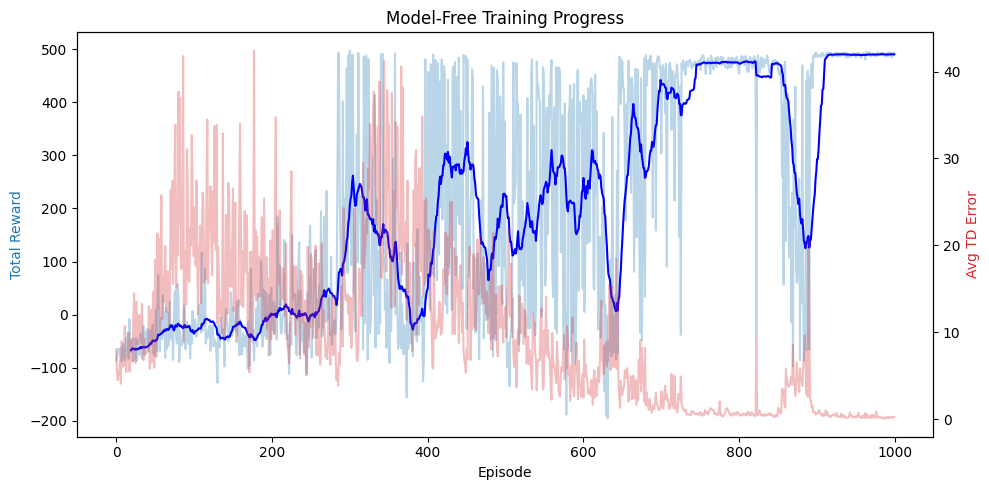

Weights saved to q_lambda_cartpole.pkl
Recording 10 episodes to q_learning.mp4...


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default


Finished Episode 1 with Score: 391.01318359375
Finished Episode 2 with Score: 390.626708984375
Finished Episode 3 with Score: 387.5707702636719
Finished Episode 4 with Score: 392.01092529296875
Finished Episode 5 with Score: 391.7104187011719
Finished Episode 6 with Score: 385.32965087890625
Finished Episode 7 with Score: 388.33251953125
Finished Episode 8 with Score: 392.29302978515625
Finished Episode 9 with Score: 392.732421875
Finished Episode 10 with Score: 387.6808166503906
Video saved as q_learning.mp4


In [10]:
import numpy as np
import gymnasium as gym
from scipy.sparse import lil_matrix, csr_matrix
from tqdm import tqdm
import pickle
import os
from scipy.sparse import save_npz, load_npz
import cv2
import matplotlib.pyplot as plt

class QLearningCartPole:
    def __init__(self, bins_per_dim=10, epsilon_init=1, epsilon_decay=0.995, min_epsilon=0.01, alpha=0.1, gamma=0.99, lambd=0.9):
        self.env = gym.make('CartPole-v1')
        # Define bins
        self.bins = [np.linspace(-2.4, 2.4, bins_per_dim),
                     np.linspace(-3.0, 3.0, bins_per_dim),
                     np.linspace(-0.21, 0.21, bins_per_dim),
                     np.linspace(-3.5, 3.5, bins_per_dim)]
        
        self.state_sizes = [len(b) + 1 for b in self.bins]
        self.num_states = int(np.prod(self.state_sizes))
        # Q-Table: (num_states, 2)
        self.Q = np.zeros((self.num_states, 2))
        
        # Eligibility Traces: (num_states, 2)
        self.E = np.zeros((self.num_states, 2))
        
        # Parameters
        self.epsilon = epsilon_init         # Exploration
        self.min_epsilon = min_epsilon      # Minimum epsilon
        self.epsilon_decay = epsilon_decay  # Epsilon decay rate
        self.alpha = alpha                  # Learning rate
        self.gamma = gamma                  # Discount factor
        self.lambd = lambd                  # 0 for SARSA, 1 for Monte Carlo

        # History to track convergence
        self.reward_history = []
        self.td_error_history = []

    def get_index(self, obs):
        indices = tuple(np.digitize(obs[i], self.bins[i]) for i in range(4))
        return np.ravel_multi_index(indices, self.state_sizes)
    
    def get_action(self, s_idx, training=True):
        """Epsilon-greedy action selection."""
        if training and np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        return np.argmax(self.Q[s_idx])

    def get_best_action(self, s_idx):
        return np.argmax(self.Q[s_idx])

    def train_episode(self):
        """A single episode of SARSA(lambda)."""
        obs, _ = self.env.reset()
        s_idx = self.get_index(obs)
        sym_s_idx = self.get_index(-np.array(obs))
        
        # Reset Eligibility Traces for the new episode
        self.E.fill(0)

        ep_errors = []
        ep_reward = 0
        
        done = False
        while not done:
            a = self.get_action(s_idx)
            next_obs, reward, term, trunc, _ = self.env.step(a)
            done = term or trunc
            
            # Custom Reward for centering (Your Formula)
            if term:
                r = -100
            else:
                r = 1.0 - (next_obs[0]**2) - (next_obs[2]**2)
            
            next_s_idx = self.get_index(next_obs)
            sym_next_s_idx = self.get_index(-np.array(next_obs))
            next_a = self.get_best_action(next_s_idx)
            
            # Q-Learning Error: delta = r + gamma * Q(s', a') - Q(s, a)
            delta = r + self.gamma * self.Q[next_s_idx, next_a] - self.Q[s_idx, a]
            ep_errors.append(abs(delta))

            # Update trace for current state-action
            self.E[s_idx, a] += 1
            self.E[sym_s_idx, 1 - a] += 1
            
            # Vectorized Update using Eligibility Traces
            self.Q += self.alpha * delta * self.E
            
            # Watkins's Q(lambda) logic:
            # If the action we just took was the greedy action, decay traces.
            # If it was exploratory, zero them out for the next step.
            if a == np.argmax(self.Q[s_idx]):
                self.E *= self.gamma * self.lambd
            else:
                self.E.fill(0)

            s_idx = next_s_idx
            sym_s_idx = sym_next_s_idx
            ep_reward += r
        
        self.reward_history.append(ep_reward)
        self.td_error_history.append(np.mean(ep_errors))
            
        return r # Return final reward for tracking
    
    def train(self, num_episodes):
        print("Training Model-Free Agent...")
        for _ in tqdm(range(num_episodes)):
            final_r = self.train_episode()
            self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)
        self.plot_learning_curve(self.reward_history, self.td_error_history)

    def plot_learning_curve(self, rewards, td_errors):
        """Used for Model-Free Reward and Error tracking"""
        fig, ax1 = plt.subplots(figsize=(10, 5))

        # Plot Rewards
        ax1.set_xlabel('Episode')
        ax1.set_ylabel('Total Reward', color='tab:blue')
        ax1.plot(rewards, color='tab:blue', alpha=0.3, label="Raw Reward")
        
        # Moving average for rewards
        window = 20
        if len(rewards) > window:
            avg_rewards = np.convolve(rewards, np.ones(window)/window, mode='valid')
            ax1.plot(range(window-1, len(rewards)), avg_rewards, color='blue', label="Moving Avg")
        
        # Plot TD Error on second axis
        ax2 = ax1.twinx()
        ax2.set_ylabel('Avg TD Error', color='tab:red')
        ax2.plot(td_errors, color='tab:red', alpha=0.3)
        
        plt.title("Model-Free Training Progress")
        fig.tight_layout()
        plt.show()
    
    def save_weights(self, filename="q_table_weights.pkl"):
        """Saves the Q-table and bin definitions."""
        data = {
            'Q': self.Q,
            'bins': self.bins,
            'state_sizes': self.state_sizes
        }
        with open(filename, 'wb') as f:
            pickle.dump(data, f)
        print(f"Weights saved to {filename}")

    def load_weights(self, filename="q_table_weights.pkl"):
        """Loads the Q-table and bin definitions."""
        if not os.path.exists(filename):
            print(f"Error: {filename} not found.")
            return
        with open(filename, 'rb') as f:
            data = pickle.load(f)
        self.Q = data['Q']
        self.bins = data['bins']
        self.state_sizes = data['state_sizes']
        print(f"Weights loaded from {filename}")

    def create_concatenated_video(self, output_name="model_free_performance.mp4", num_episodes=10):
        # 1. Setup Environment and Video Writer
        # Note: Use render_mode="rgb_array" for frame capture
        env = gym.make('CartPole-v1', render_mode="rgb_array")
        
        # Get frame dimensions
        obs, _ = env.reset()
        frame = env.render()
        height, width, layers = frame.shape
        
        # Define video codec and writer
        fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
        video = cv2.VideoWriter(output_name, fourcc, 24, (width, height))

        print(f"Recording {num_episodes} episodes to {output_name}...")

        for ep in range(1, num_episodes + 1):
            obs, _ = env.reset()
            done = False
            score = 0
            step = 0
            
            while not done:
                # 2. Get Action from Q-Table
                s_idx = self.get_index(obs)
                # During testing/recording, we use the greedy action (argmax of Q)
                action = np.argmax(self.Q[s_idx])

                # 3. Step Environment
                obs, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                
                # Using your specific centering reward for the display
                current_reward = (1.0 - obs[0]**2 - obs[2]**2) if not (terminated or truncated) else -100
                score += current_reward
                step += 1

                # 4. Capture and Process Frame
                frame = env.render()
                frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

                # 5. Overlay Text Data (Top-left corner, stacked)
                font = cv2.FONT_HERSHEY_SIMPLEX
                font_scale = 0.5
                font_thickness = 1
                color = (0, 0, 0)  # Black text as requested
                x_offset = 15

                lines = [
                    (f"Episode: {ep}", 25),
                    (f"Score: {int(score)}", 45),
                    (f"Step: {step}", 65)
                ]

                # White background box for the corner
                cv2.rectangle(frame_bgr, (5, 5), (150, 75), (255, 255, 255), -1)

                for text, y_pos in lines:
                    cv2.putText(
                        frame_bgr, 
                        text, 
                        (x_offset, y_pos), 
                        font, 
                        font_scale, 
                        color, 
                        font_thickness, 
                        cv2.LINE_AA
                    )

                # 6. Write to Video
                video.write(frame_bgr)

            print(f"Finished Episode {ep} with Score: {score}")

        # Finalize
        video.release()
        env.close()
        print(f"Video saved as {output_name}")

# Initialize agent (lambda=0.9 for SARSA-lambda)
agent = QLearningCartPole(bins_per_dim=12, epsilon_init=0.5, epsilon_decay=0.995, min_epsilon=0.001, alpha=0.1, gamma=0.99, lambd=0.9)

# 1. Training
agent.train(num_episodes=1000)

# 2. Save the learned Q-Table
agent.save_weights("q_lambda_cartpole.pkl")

# 3. Create the High-Clarity Video
agent.create_concatenated_video("q_learning.mp4", num_episodes=10)

In [11]:
import numpy as np
import pickle

def check_q_symmetry(weights_path="q_lambda_cartpole.pkl"):
    # 1. Load the learned data
    with open(weights_path, 'rb') as f:
        data = pickle.load(f)
    
    Q = data['Q']
    bins = data['bins']
    state_sizes = data['state_sizes']
    num_states = Q.shape[0]
    
    print(f"Analyzing Symmetry for {num_states} states...")

    total_error = 0
    comparisons = 0

    # We iterate through all states to find their "mirrors"
    for s_idx in range(num_states):
        # Convert flat index back to multi-dimensional grid coordinates
        coords = np.unravel_index(s_idx, state_sizes)
        
        # Calculate the "mirrored" coordinates
        # In CartPole, the bins are symmetric around the center. 
        # If a bin index is 'i', its mirror is 'max_bins - i'
        mirrored_coords = tuple((state_sizes[i] - 1) - coords[i] for i in range(4))
        mirrored_idx = np.ravel_multi_index(mirrored_coords, state_sizes)

        # Skip if we've already compared this pair or if it's the same state
        if s_idx >= mirrored_idx:
            continue

        # Symmetry Condition: Q(s, Left) should equal Q(s_mirror, Right)
        # Action 0 = Left, Action 1 = Right
        val_left = Q[s_idx, 0]
        val_right_mirrored = Q[mirrored_idx, 1]

        error = abs(val_left - val_right_mirrored)
        total_error += error
        comparisons += 1

    avg_symmetry_error = total_error / comparisons if comparisons > 0 else 0
    
    print("-" * 30)
    print(f"Mean Symmetry Error: {avg_symmetry_error:.6f}")
    
    if avg_symmetry_error < 0.1:
        print("RESULT: Highly Symmetric (Low Sampling Bias)")
    elif avg_symmetry_error < 1.0:
        print("RESULT: Moderately Symmetric (Some Bias detected)")
    else:
        print("RESULT: Asymmetric (High Sampling Bias - Needs more training or exploration)")
    print("-" * 30)

# Run the check
check_q_symmetry("q_lambda_cartpole.pkl")

Analyzing Symmetry for 28561 states...
------------------------------
Mean Symmetry Error: 0.000000
RESULT: Highly Symmetric (Low Sampling Bias)
------------------------------
